In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv("/content/Sample-Superstore.csv")
df

,csvbase_row_id,﻿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   csvbase_row_id  9994 non-null   int64  
 1   ﻿Row ID         9994 non-null   int64  
 2   Order ID        9994 non-null   object 
 3   Order Date      9994 non-null   object 
 4   Ship Date       9994 non-null   object 
 5   Ship Mode       9994 non-null   object 
 6   Customer ID     9994 non-null   object 
 7   Customer Name   9994 non-null   object 
 8   Segment         9994 non-null   object 
 9   Country         9994 non-null   object 
 10  City            9994 non-null   object 
 11  State           9994 non-null   object 
 12  Postal Code     9994 non-null   int64  
 13  Region          9994 non-null   object 
 14  Product ID      9994 non-null   object 
 15  Category        9994 non-null   object 
 16  Sub-Category    9994 non-null   object 
 17  Product Name    9994 non-null   o

# **Sales By Category :**

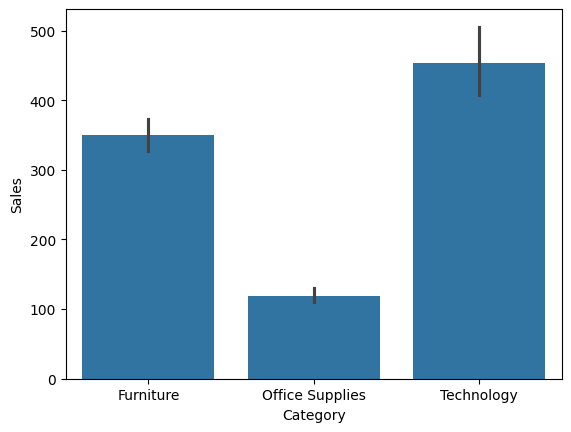

In [8]:
sns.barplot(x='Category',y='Sales',data=df)
plt.show()

# **Profit By Category :**

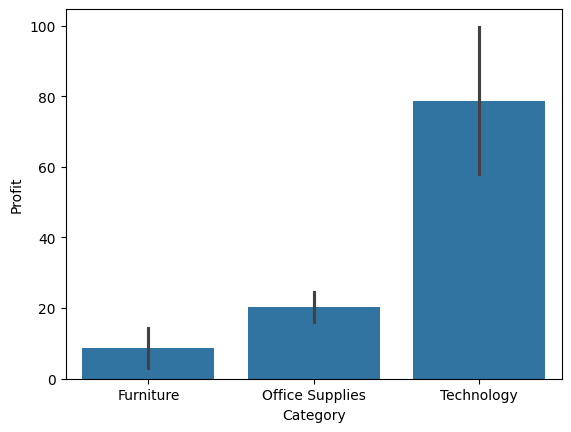

In [9]:
sns.barplot(x = 'Category', y = 'Profit', data = df)
plt.show()

# **Top Products :**

In [10]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
print(top_products)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


# **Monthly Trends :**

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


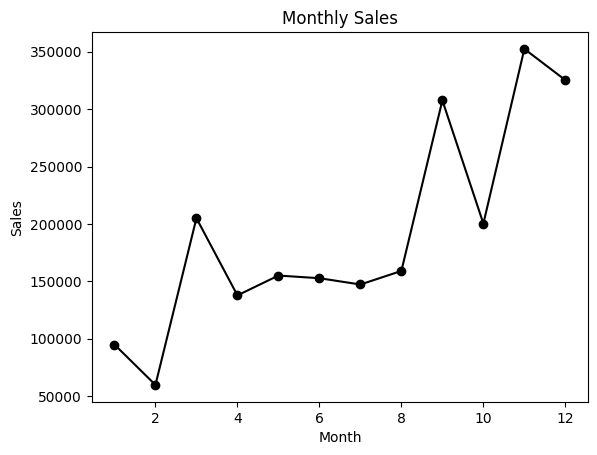

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)
monthly_sales.plot(marker = 'o' , color = 'black')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales')
plt.xticks(rotation = 0)
plt.show()

# **Sales vs Proft :**

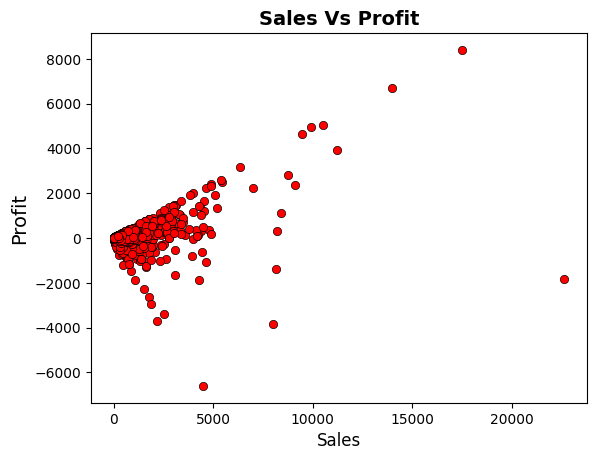

In [30]:
sns.scatterplot(x='Sales',y='Profit',data=df , color = 'red',edgecolor = 'black')
plt.title('Sales Vs Profit', fontsize = 14,fontweight = 'bold')
plt.xlabel('Sales', fontsize = 12)
plt.ylabel('Profit', fontsize = 14)
plt.show()


## **INSIGHTS :-**

* Technology category generates the highest sales and profit.
* Sales peak in the month of December.
* Sales show variation across different months (seasonality observed).
* Some products generate high sales but low profit, indicating low margins.
* Furniture category has the lowest profit but is still profitable.